In [1]:
import polars as pl
import os

# Diretório dos dados
data_dir = '../data'

# Carregar dados de 2022, 2023 e 2024 (formato antigo - arquivo único)
# Usar separator em vez de sep e ignore_errors para lidar com problemas de parsing
df_2022 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2022/microdados/dados/microdados_ed_basica_2022.csv', separator=';', encoding='latin-1', ignore_errors=True)
df_2023 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv', separator=';', encoding='latin-1', ignore_errors=True)
df_2024 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2024/dados/microdados_ed_basica_2024.csv', separator=';', encoding='latin-1', ignore_errors=True)

# Carregar dados de 2025 (novo formato - tabelas separadas)
# Vamos carregar a Tabela_Matricula_2025 que contém as matrículas
df_matricula_2025 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Matricula_2025.csv', separator=';', encoding='latin-1', ignore_errors=True)
df_escola_2025 = pl.read_csv(f'{data_dir}/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Escola_2025.csv', separator=';', encoding='latin-1', ignore_errors=True)

print(f"2022: {df_2022.shape}")
print(f"2023: {df_2023.shape}")
print(f"2024: {df_2024.shape}")
print(f"2025 Matrícula: {df_matricula_2025.shape}")
print(f"2025 Escola: {df_escola_2025.shape}")

2022: (224649, 385)
2023: (217625, 408)
2024: (215545, 426)
2025 Matrícula: (178766, 237)
2025 Escola: (214192, 302)


In [2]:
import pandas as pd

# Converter dataframes Polars para Pandas
df_2022 = df_2022.to_pandas()
df_2023 = df_2023.to_pandas()
df_2024 = df_2024.to_pandas()
df_matricula_2025 = df_matricula_2025.to_pandas()
df_escola_2025 = df_escola_2025.to_pandas()

# Encontrar colunas comuns entre todos os dataframes
cols_2022 = set(df_2022.columns)
cols_2023 = set(df_2023.columns)
cols_2024 = set(df_2024.columns)
cols_matricula_2025 = set(df_matricula_2025.columns)
cols_escola_2025 = set(df_escola_2025.columns)

# Colunas comuns em 2022, 2023 e 2024
cols_comuns_22_23_24 = cols_2022 & cols_2023 & cols_2024
print(f"Colunas comuns em 2022, 2023 e 2024: {len(cols_comuns_22_23_24)}")
print(sorted(cols_comuns_22_23_24)[:20], "...")

# Colunas comuns em 2025 (matrícula e escola)
cols_comuns_2025 = cols_matricula_2025 & cols_escola_2025
print(f"\nColunas comuns em 2025 (matrícula e escola): {len(cols_comuns_2025)}")
print(sorted(cols_comuns_2025)[:20], "...")

Colunas comuns em 2022, 2023 e 2024: 337
['CO_CEP', 'CO_DISTRITO', 'CO_ENTIDADE', 'CO_ESCOLA_SEDE_VINCULADA', 'CO_IES_OFERTANTE', 'CO_LINGUA_INDIGENA_1', 'CO_LINGUA_INDIGENA_2', 'CO_LINGUA_INDIGENA_3', 'CO_MESORREGIAO', 'CO_MICRORREGIAO', 'CO_MUNICIPIO', 'CO_ORGAO_REGIONAL', 'CO_REGIAO', 'CO_UF', 'DS_COMPLEMENTO', 'DS_ENDERECO', 'DT_ANO_LETIVO_INICIO', 'DT_ANO_LETIVO_TERMINO', 'IN_ACESSIBILIDADE_CORRIMAO', 'IN_ACESSIBILIDADE_ELEVADOR'] ...

Colunas comuns em 2025 (matrícula e escola): 2
['CO_ENTIDADE', 'NU_ANO_CENSO'] ...


In [5]:
df_2025_merged = pd.merge(df_escola_2025, df_matricula_2025, on='CO_ENTIDADE')


In [6]:
# Adicionar coluna ANO_CENSO a cada dataframe
df_2022['ANO_CENSO'] = 2022
df_2023['ANO_CENSO'] = 2023
df_2024['ANO_CENSO'] = 2024
df_2025_merged['ANO_CENSO'] = 2025

# Encontrar colunas comuns entre todos os dataframes
cols_2022 = set(df_2022.columns)
cols_2023 = set(df_2023.columns)
cols_2024 = set(df_2024.columns)
cols_2025 = set(df_2025_merged.columns)

cols_comuns = cols_2022 & cols_2023 & cols_2024 & cols_2025
cols_comuns_lista = sorted(list(cols_comuns))

print(f"Colunas comuns em todos os anos: {len(cols_comuns_lista)}")
print(f"Primeiras 20 colunas comuns: {cols_comuns_lista[:20]}")

# Selecionar apenas as colunas comuns de cada dataframe
df_2022_common = df_2022[cols_comuns_lista].copy()
df_2023_common = df_2023[cols_comuns_lista].copy()
df_2024_common = df_2024[cols_comuns_lista].copy()
df_2025_common = df_2025_merged[cols_comuns_lista].copy()

print(f"\n2022 (colunas comuns): {df_2022_common.shape}")
print(f"2023 (colunas comuns): {df_2023_common.shape}")
print(f"2024 (colunas comuns): {df_2024_common.shape}")
print(f"2025 (colunas comuns): {df_2025_common.shape}")

# Concatenar todos os dataframes
df_total = pd.concat([df_2022_common, df_2023_common, df_2024_common, df_2025_common], ignore_index=True)
print(f"\nDataframe total (2022-2025): {df_total.shape}")
print(f"Distribuição por ano:")
print(df_total['ANO_CENSO'].value_counts().sort_index())

Colunas comuns em todos os anos: 273
Primeiras 20 colunas comuns: ['ANO_CENSO', 'CO_CEP', 'CO_DISTRITO', 'CO_ENTIDADE', 'CO_ESCOLA_SEDE_VINCULADA', 'CO_IES_OFERTANTE', 'CO_LINGUA_INDIGENA_1', 'CO_LINGUA_INDIGENA_2', 'CO_LINGUA_INDIGENA_3', 'CO_MESORREGIAO', 'CO_MICRORREGIAO', 'CO_MUNICIPIO', 'CO_ORGAO_REGIONAL', 'CO_REGIAO', 'CO_UF', 'DS_COMPLEMENTO', 'DS_ENDERECO', 'DT_ANO_LETIVO_INICIO', 'DT_ANO_LETIVO_TERMINO', 'IN_ACESSIBILIDADE_CORRIMAO']



2022 (colunas comuns): (224649, 273)
2023 (colunas comuns): (217625, 273)
2024 (colunas comuns): (215545, 273)
2025 (colunas comuns): (178766, 273)

Dataframe total (2022-2025): (836585, 273)
Distribuição por ano:
ANO_CENSO
2022    224649
2023    217625
2024    215545
2025    178766
Name: count, dtype: int64


Colunas encontradas: ['QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_EJA_MED']


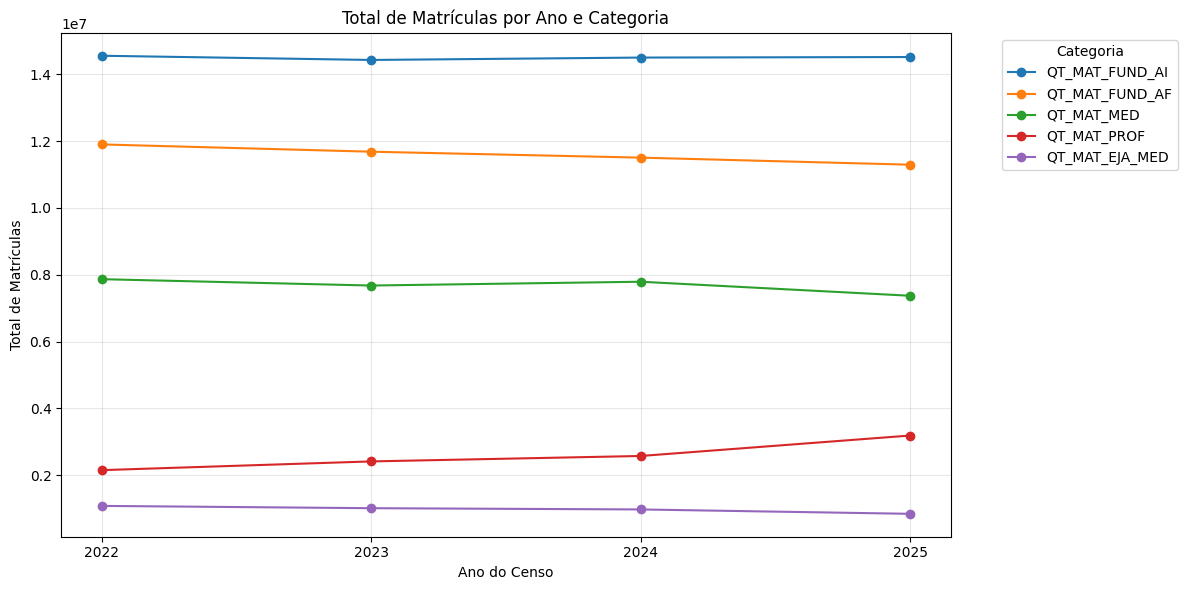


Tabela de matrículas por ano:
           QT_MAT_FUND_AI  QT_MAT_FUND_AF  QT_MAT_MED  QT_MAT_PROF  \
ANO_CENSO                                                            
2022           14553030.0      11899198.0   7866695.0    2152506.0   
2023           14426650.0      11681558.0   7676743.0    2413825.0   
2024           14498233.0      11504123.0   7790396.0    2576293.0   
2025           14514244.0      11292523.0   7370879.0    3187976.0   

           QT_MAT_EJA_MED  
ANO_CENSO                  
2022            1082607.0  
2023            1014011.0  
2024             976390.0  
2025             845627.0  


In [7]:
import matplotlib.pyplot as plt

# Colunas de matrícula a serem analisadas
colunas_matricula = [
    'QT_MAT_FUND_AI',      # Fundamental anos iniciais
    'QT_MAT_FUND_AF',      # Fundamental anos finais
    'QT_MAT_MED',          # Ensino médio
    'QT_MAT_PROF',         # Ensino profissionalizante
    'QT_MAT_EJA_MED'       # EJA ensino médio
]

# Verificar quais colunas existem no dataframe
colunas_existentes = [col for col in colunas_matricula if col in df_total.columns]
print(f"Colunas encontradas: {colunas_existentes}")

if colunas_existentes:
    # Agrupar por ano e somar as matrículas
    matriculas_por_ano = df_total.groupby('ANO_CENSO')[colunas_existentes].sum()
    
    # Plotar gráfico de linhas
    plt.figure(figsize=(12, 6))
    for coluna in colunas_existentes:
        plt.plot(matriculas_por_ano.index, matriculas_por_ano[coluna], marker='o', label=coluna)
    
    plt.title('Total de Matrículas por Ano e Categoria')
    plt.xlabel('Ano do Censo')
    plt.ylabel('Total de Matrículas')
    plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(matriculas_por_ano.index)
    plt.tight_layout()
    plt.show()
    
    # Exibir tabela com valores
    print("\nTabela de matrículas por ano:")
    print(matriculas_por_ano)
else:
    print("Nenhuma das colunas de matrícula especificadas foi encontrada no dataframe.")

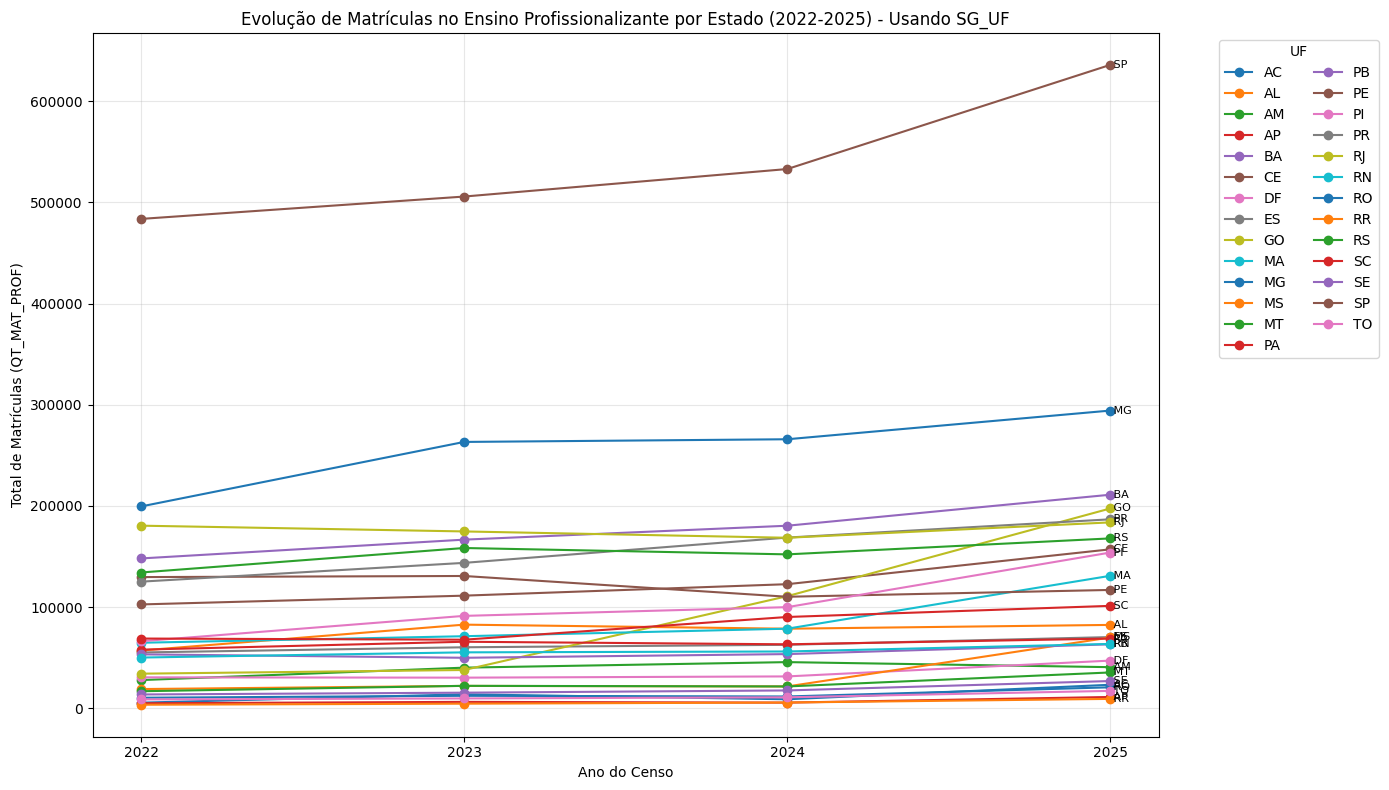


Tabela de matrículas no ensino profissionalizante por estado e ano (usando SG_UF):
ANO_CENSO      2022      2023      2024      2025
SG_UF                                            
AC           5544.0   13823.0    8906.0   23252.0
AL          57096.0   82672.0   78647.0   82406.0
AM          27873.0   40162.0   45630.0   40640.0
AP           4959.0    6335.0    5605.0   11186.0
BA         148103.0  166677.0  180445.0  211101.0
CE         102644.0  111322.0  122657.0  157127.0
DF          30578.0   30280.0   31500.0   47130.0
ES          55166.0   60297.0   62746.0   70383.0
GO          34207.0   37839.0  110807.0  197542.0
MA          64770.0   71229.0   78667.0  130969.0
MG         199488.0  263261.0  265906.0  294273.0
MS          19005.0   22111.0   21585.0   69997.0
MT          16857.0   22193.0   21586.0   35420.0
PA          57936.0   65765.0   63232.0   68916.0
PB          53312.0   49917.0   53565.0   63218.0
PE         129678.0  130763.0  110230.0  116976.0
PI          6627

In [12]:
import matplotlib.pyplot as plt

# Verificar qual coluna de estado usar: SG_UF (sigla) ou CO_UF (código)
coluna_uf = 'SG_UF' if 'SG_UF' in df_total.columns else 'CO_UF'

if coluna_uf in df_total.columns and 'QT_MAT_PROF' in df_total.columns:
    # Agrupar por estado e ano, somando QT_MAT_PROF
    matriculas_prof_por_uf_ano = df_total.groupby([coluna_uf, 'ANO_CENSO'])['QT_MAT_PROF'].sum().unstack()
    
    # Plotar gráfico de linhas - uma linha por estado
    plt.figure(figsize=(14, 8))
    for uf in matriculas_prof_por_uf_ano.index:
        plt.plot(matriculas_prof_por_uf_ano.columns, matriculas_prof_por_uf_ano.loc[uf], marker='o', label=uf)
        # Adicionar texto com a sigla da UF no final da linha
        ultimo_ano = matriculas_prof_por_uf_ano.columns[-1]
        valor_final = matriculas_prof_por_uf_ano.loc[uf, ultimo_ano]
        plt.text(ultimo_ano, valor_final, f' {uf}', fontsize=8, va='center')
    
    plt.title(f'Evolução de Matrículas no Ensino Profissionalizante por Estado (2022-2025) - Usando {coluna_uf}')
    plt.xlabel('Ano do Censo')
    plt.ylabel('Total de Matrículas (QT_MAT_PROF)')
    plt.legend(title='UF', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.xticks(sorted(df_total['ANO_CENSO'].unique()))
    plt.tight_layout()
    plt.show()
    
    # Exibir tabela com valores
    print(f"\nTabela de matrículas no ensino profissionalizante por estado e ano (usando {coluna_uf}):")
    print(matriculas_prof_por_uf_ano)
else:
    print(f"Colunas {coluna_uf} ou QT_MAT_PROF não encontradas no dataframe.")

In [13]:
# Calcular crescimento ano a ano do QT_MAT_PROF por estado
coluna_uf = 'SG_UF' if 'SG_UF' in df_total.columns else 'CO_UF'

if coluna_uf in df_total.columns and 'QT_MAT_PROF' in df_total.columns:
    # Agrupar por estado e ano, somando QT_MAT_PROF
    matriculas_prof_por_uf_ano = df_total.groupby([coluna_uf, 'ANO_CENSO'])['QT_MAT_PROF'].sum().unstack()
    
    # Calcular crescimento ano a ano
    crescimento = matriculas_prof_por_uf_ano.pct_change(axis=1) * 100  # Percentual de crescimento
    
    print("Crescimento ano a ano do QT_MAT_PROF por estado (%):")
    print(crescimento.round(2))
    
    # Focar no crescimento de 2024 para 2025
    if 2025 in crescimento.columns:
        crescimento_2024_2025 = crescimento[2025].sort_values(ascending=False)
        
        print(f"\n{'='*60}")
        print(f"ESTADOS COM MAIOR CRESCIMENTO DE QT_MAT_PROF (2024 -> 2025)")
        print(f"{'='*60}")
        
        # Criar tabela com valores absolutos e crescimento
        tabela_crescimento = pd.DataFrame({
            'QT_MAT_PROF_2024': matriculas_prof_por_uf_ano[2024],
            'QT_MAT_PROF_2025': matriculas_prof_por_uf_ano[2025],
            'Crescimento_%': crescimento_2024_2025
        }).dropna()
        
        # Ordenar por crescimento
        tabela_crescimento = tabela_crescimento.sort_values('Crescimento_%', ascending=False)
        
        print(tabela_crescimento.head(10).round(2))
        
        # Exibir todos os estados ordenados
        print(f"\n{'='*60}")
        print(f"TODOS OS ESTADOS ORDENADOS POR CRESCIMENTO (2024 -> 2025)")
        print(f"{'='*60}")
        print(tabela_crescimento.round(2))
else:
    print(f"Colunas {coluna_uf} ou QT_MAT_PROF não encontradas no dataframe.")

Crescimento ano a ano do QT_MAT_PROF por estado (%):
ANO_CENSO  2022    2023    2024    2025
SG_UF                                  
AC          NaN  149.33  -35.57  161.08
AL          NaN   44.79   -4.87    4.78
AM          NaN   44.09   13.61  -10.94
AP          NaN   27.75  -11.52   99.57
BA          NaN   12.54    8.26   16.99
CE          NaN    8.45   10.18   28.10
DF          NaN   -0.97    4.03   49.62
ES          NaN    9.30    4.06   12.17
GO          NaN   10.62  192.84   78.28
MA          NaN    9.97   10.44   66.49
MG          NaN   31.97    1.00   10.67
MS          NaN   16.34   -2.38  224.29
MT          NaN   31.65   -2.74   64.09
PA          NaN   13.51   -3.85    8.99
PB          NaN   -6.37    7.31   18.02
PE          NaN    0.84  -15.70    6.12
PI          NaN   37.81    9.45   54.02
PR          NaN   14.84   17.40   10.70
RJ          NaN   -3.16   -3.58    9.02
RN          NaN   10.23    1.54   13.32
RO          NaN   18.22   -5.40   77.75
RR          NaN   29.56   2

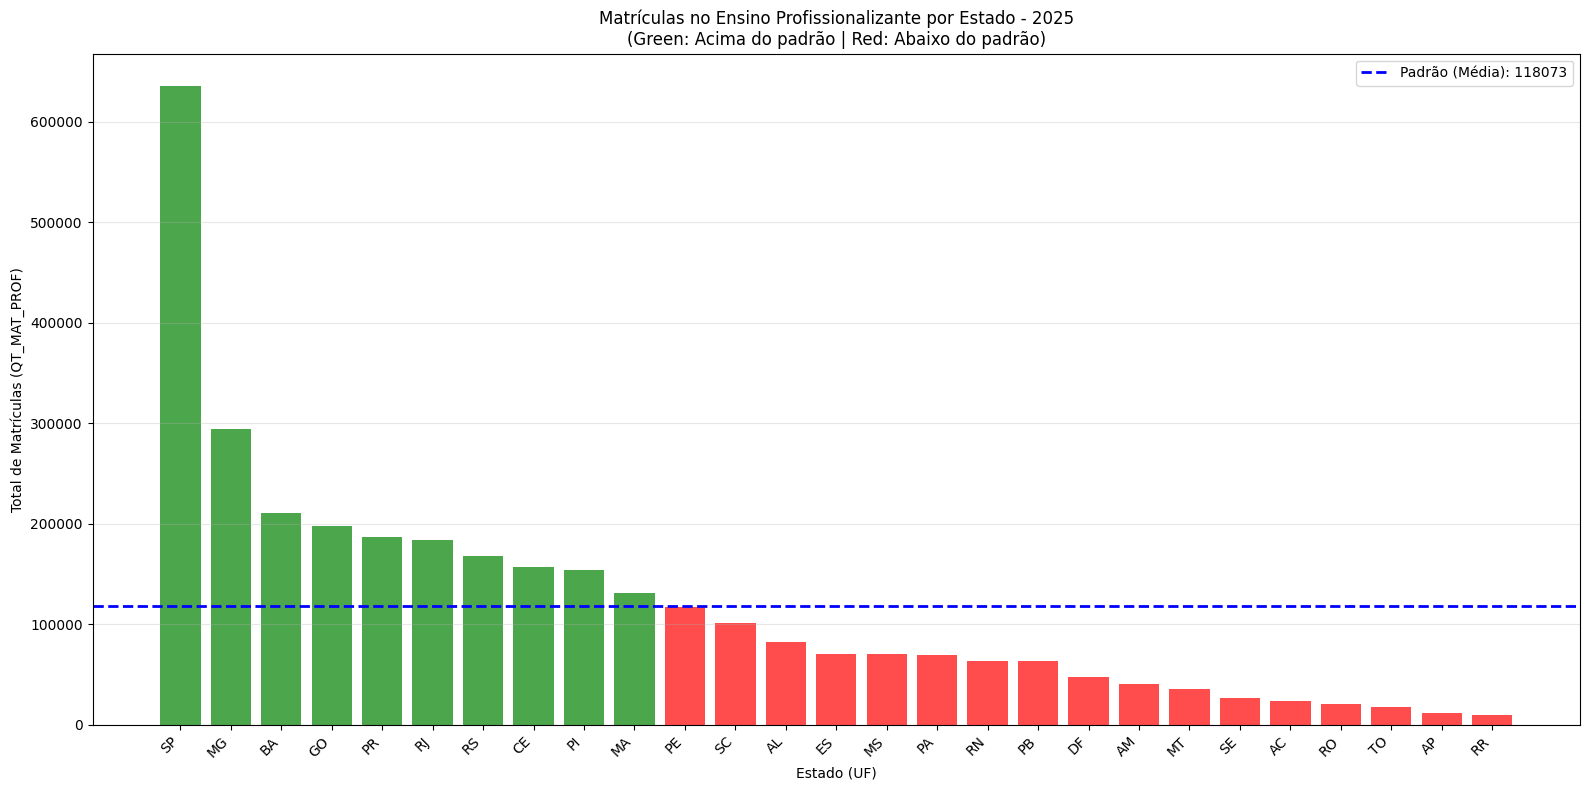

ANÁLISE DE QT_MAT_PROF POR ESTADO - 2025

Padrão (Média): 118073 matrículas

Estados ACIMA do padrão (10):
SG_UF
SP    635989.0
MG    294273.0
BA    211101.0
GO    197542.0
PR    186789.0
RJ    183746.0
RS    167917.0
CE    157127.0
PI    153957.0
MA    130969.0
Name: QT_MAT_PROF, dtype: float64

Estados ABAIXO do padrão (17):
SG_UF
PE    116976.0
SC    101245.0
AL     82406.0
ES     70383.0
MS     69997.0
PA     68916.0
RN     63620.0
PB     63218.0
DF     47130.0
AM     40640.0
MT     35420.0
SE     26938.0
AC     23252.0
RO     20745.0
TO     17209.0
AP     11186.0
RR      9285.0
Name: QT_MAT_PROF, dtype: float64

TABELA RESUMO - QT_MAT_PROF 2025
Estado  QT_MAT_PROF  Diferença_vs_Padrão Status
    SP     635989.0        517915.814815  Acima
    MG     294273.0        176199.814815  Acima
    BA     211101.0         93027.814815  Acima
    GO     197542.0         79468.814815  Acima
    PR     186789.0         68715.814815  Acima
    RJ     183746.0         65672.814815  Acima
    RS

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Verificar qual coluna de estado usar
coluna_uf = 'SG_UF' if 'SG_UF' in df_total.columns else 'CO_UF'

if coluna_uf in df_total.columns and 'QT_MAT_PROF' in df_total.columns:
    # Filtrar dados de 2025 e agrupar por estado
    dados_2025 = df_total[df_total['ANO_CENSO'] == 2025].groupby(coluna_uf)['QT_MAT_PROF'].sum().sort_values(ascending=False)
    
    # Calcular o padrão (média)
    padrao = dados_2025.mean()
    
    # Classificar estados
    acima_padrao = dados_2025[dados_2025 > padrao]
    no_padrao = dados_2025[dados_2025 == padrao]
    abaixo_padrao = dados_2025[dados_2025 < padrao]
    
    # Criar gráfico de barras
    plt.figure(figsize=(16, 8))
    
    # Plotar barras com cores baseadas na relação com o padrão
    cores = []
    for uf in dados_2025.index:
        if dados_2025[uf] > padrao:
            cores.append('green')  # Acima do padrão
        elif dados_2025[uf] < padrao:
            cores.append('red')    # Abaixo do padrão
        else:
            cores.append('gray')   # No padrão
    
    bars = plt.bar(range(len(dados_2025)), dados_2025.values, color=cores, alpha=0.7)
    
    # Adicionar linha do padrão
    plt.axhline(y=padrao, color='blue', linestyle='--', linewidth=2, label=f'Padrão (Média): {padrao:.0f}')
    
    # Adicionar rótulos
    plt.xticks(range(len(dados_2025)), dados_2025.index, rotation=45, ha='right')
    plt.xlabel('Estado (UF)')
    plt.ylabel('Total de Matrículas (QT_MAT_PROF)')
    plt.title('Matrículas no Ensino Profissionalizante por Estado - 2025\n(Green: Acima do padrão | Red: Abaixo do padrão)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Exibir estatísticas
    print(f"{'='*70}")
    print(f"ANÁLISE DE QT_MAT_PROF POR ESTADO - 2025")
    print(f"{'='*70}")
    print(f"\nPadrão (Média): {padrao:.0f} matrículas")
    print(f"\nEstados ACIMA do padrão ({len(acima_padrao)}):")
    print(acima_padrao.round(0))
    print(f"\nEstados ABAIXO do padrão ({len(abaixo_padrao)}):")
    print(abaixo_padrao.round(0))
    if len(no_padrao) > 0:
        print(f"\nEstados NO padrão ({len(no_padrao)}):")
        print(no_padrao.round(0))
    
    # Tabela resumo
    print(f"\n{'='*70}")
    print(f"TABELA RESUMO - QT_MAT_PROF 2025")
    print(f"{'='*70}")
    tabela_resumo = pd.DataFrame({
        'Estado': dados_2025.index,
        'QT_MAT_PROF': dados_2025.values,
        'Diferença_vs_Padrão': dados_2025.values - padrao,
        'Status': np.where(dados_2025.values > padrao, 'Acima', 
                          np.where(dados_2025.values < padrao, 'Abaixo', 'No padrão'))
    }).sort_values('QT_MAT_PROF', ascending=False)
    print(tabela_resumo.to_string(index=False))
else:
    print(f"Colunas {coluna_uf} ou QT_MAT_PROF não encontradas no dataframe.")

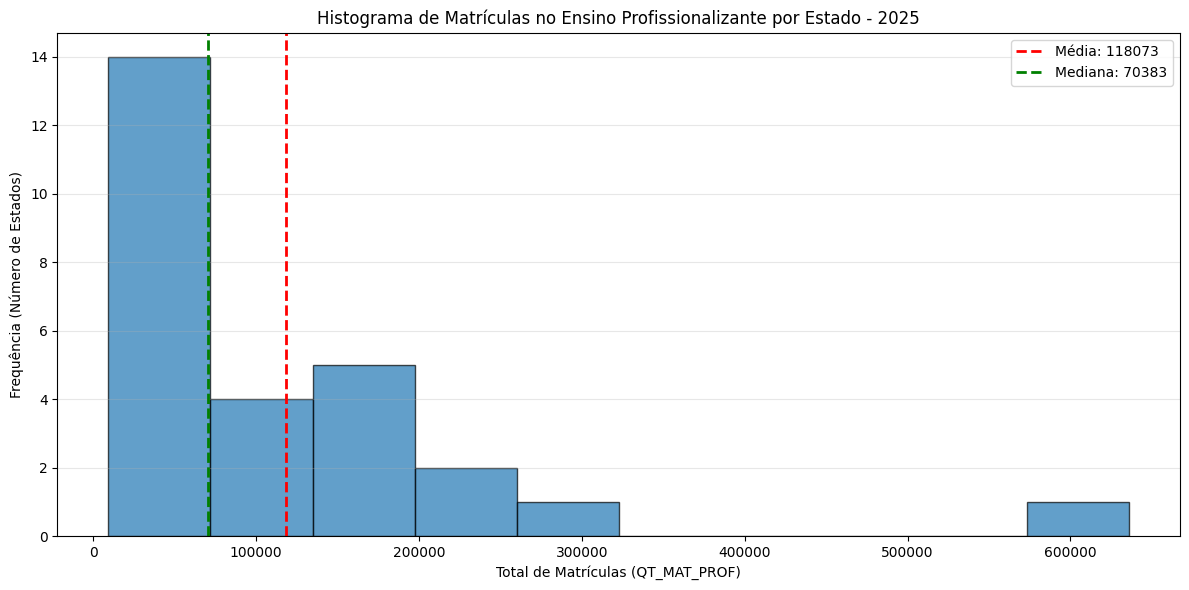

ESTATÍSTICAS DE QT_MAT_PROF POR ESTADO - 2025

Média: 118073 matrículas
Mediana: 70383 matrículas
Desvio Padrão: 127301 matrículas
Valor Mínimo: 9285 matrículas
Valor Máximo: 635989 matrículas
Total de Estados: 27

DADOS POR ESTADO - 2025
SG_UF
SP    635989.0
MG    294273.0
BA    211101.0
GO    197542.0
PR    186789.0
RJ    183746.0
RS    167917.0
CE    157127.0
PI    153957.0
MA    130969.0
PE    116976.0
SC    101245.0
AL     82406.0
ES     70383.0
MS     69997.0
PA     68916.0
RN     63620.0
PB     63218.0
DF     47130.0
AM     40640.0
MT     35420.0
SE     26938.0
AC     23252.0
RO     20745.0
TO     17209.0
AP     11186.0
RR      9285.0
Name: QT_MAT_PROF, dtype: float64


In [15]:
import matplotlib.pyplot as plt

# Verificar qual coluna de estado usar
coluna_uf = 'SG_UF' if 'SG_UF' in df_total.columns else 'CO_UF'

if coluna_uf in df_total.columns and 'QT_MAT_PROF' in df_total.columns:
    # Filtrar dados de 2025 e agrupar por estado
    dados_2025 = df_total[df_total['ANO_CENSO'] == 2025].groupby(coluna_uf)['QT_MAT_PROF'].sum()
    
    # Criar histograma
    plt.figure(figsize=(12, 6))
    plt.hist(dados_2025.values, bins=10, edgecolor='black', alpha=0.7)
    plt.axvline(dados_2025.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {dados_2025.mean():.0f}')
    plt.axvline(dados_2025.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {dados_2025.median():.0f}')
    
    plt.xlabel('Total de Matrículas (QT_MAT_PROF)')
    plt.ylabel('Frequência (Número de Estados)')
    plt.title('Histograma de Matrículas no Ensino Profissionalizante por Estado - 2025')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Exibir estatísticas
    print(f"{'='*70}")
    print(f"ESTATÍSTICAS DE QT_MAT_PROF POR ESTADO - 2025")
    print(f"{'='*70}")
    print(f"\nMédia: {dados_2025.mean():.0f} matrículas")
    print(f"Mediana: {dados_2025.median():.0f} matrículas")
    print(f"Desvio Padrão: {dados_2025.std():.0f} matrículas")
    print(f"Valor Mínimo: {dados_2025.min():.0f} matrículas")
    print(f"Valor Máximo: {dados_2025.max():.0f} matrículas")
    print(f"Total de Estados: {len(dados_2025)}")
    
    # Exibir dados brutos
    print(f"\n{'='*70}")
    print(f"DADOS POR ESTADO - 2025")
    print(f"{'='*70}")
    print(dados_2025.sort_values(ascending=False))
else:
    print(f"Colunas {coluna_uf} ou QT_MAT_PROF não encontradas no dataframe.")

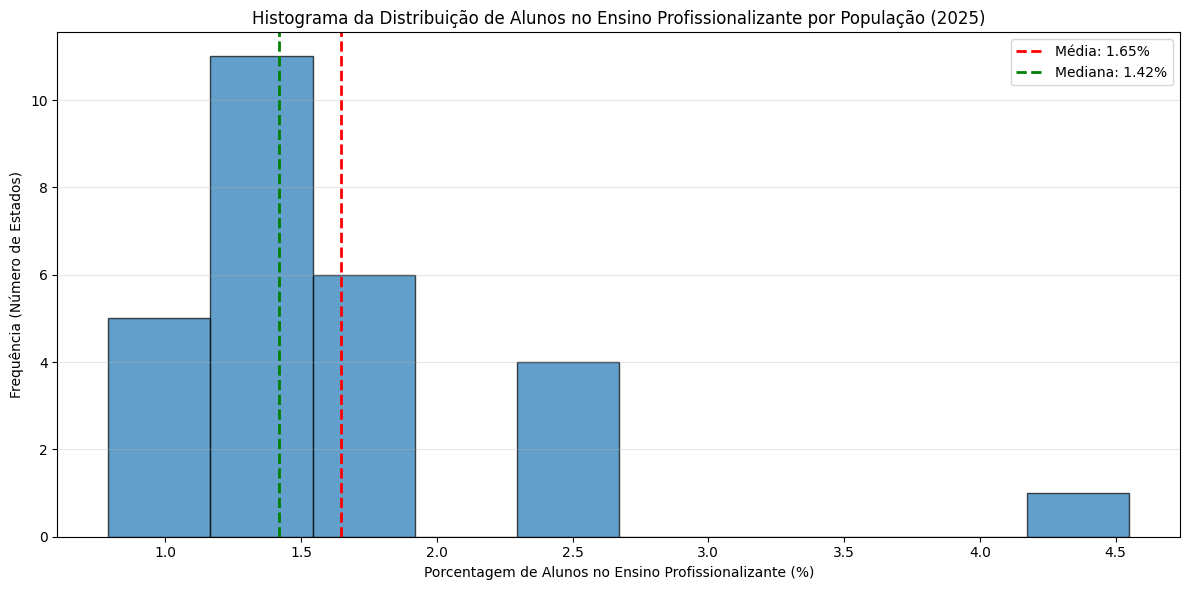

ESTATÍSTICAS - PORCENTAGEM DE ALUNOS POR POPULAÇÃO (2025)

Média: 1.65%
Mediana: 1.42%
Desvio Padrão: 0.77%
Valor Mínimo: 0.79%
Valor Máximo: 4.55%
Total de Estados: 27

DADOS POR ESTADO - PORCENTAGEM DE ALUNOS (2025)
PI: 4.55%
GO: 2.66%
AC: 2.63%
AL: 2.56%
MS: 2.39%
MA: 1.87%
RN: 1.84%
ES: 1.71%
CE: 1.70%
DF: 1.57%
PR: 1.57%
PB: 1.52%
RS: 1.49%
BA: 1.42%
AP: 1.39%
SP: 1.38%
MG: 1.38%
RR: 1.26%
SC: 1.24%
PE: 1.22%
RO: 1.18%
SE: 1.17%
TO: 1.08%
RJ: 1.07%
AM: 0.94%
MT: 0.91%
PA: 0.79%


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Dados de população por estado (IBGE 2025)
populacao_por_estado = {
    'SP': 46081801,
    'MG': 21393441,
    'RJ': 17223547,
    'BA': 14870907,
    'PR': 11890517,
    'RS': 11233263,
    'PE': 9562007,
    'CE': 9268836,
    'PA': 8711196,
    'SC': 8187029,
    'GO': 7423629,
    'MA': 7018211,
    'AM': 4321616,
    'PB': 4164468,
    'ES': 4126854,
    'MT': 3893659,
    'RN': 3455236,
    'PI': 3384547,
    'AL': 3220848,
    'DF': 2996899,
    'MS': 2924631,
    'SE': 2299425,
    'RO': 1751950,
    'TO': 1586859,
    'AC': 884372,
    'AP': 806517,
    'RR': 738772
}

# Verificar qual coluna de estado usar
coluna_uf = 'SG_UF' if 'SG_UF' in df_total.columns else 'CO_UF'

if coluna_uf in df_total.columns and 'QT_MAT_PROF' in df_total.columns:
    # Filtrar dados de 2025 e agrupar por estado
    dados_2025 = df_total[df_total['ANO_CENSO'] == 2025].groupby(coluna_uf)['QT_MAT_PROF'].sum()
    
    # Calcular porcentagem de alunos em relação à população
    porcentagens = []
    estados = []
    for estado, matriculas in dados_2025.items():
        if estado in populacao_por_estado:
            pop = populacao_por_estado[estado]
            porcentagem = (matriculas / pop) * 100
            porcentagens.append(porcentagem)
            estados.append(estado)
    
    # Criar série com as porcentagens
    serie_porcentagens = pd.Series(porcentagens, index=estados)
    
    # Criar histograma
    plt.figure(figsize=(12, 6))
    plt.hist(serie_porcentagens.values, bins=10, edgecolor='black', alpha=0.7)
    plt.axvline(serie_porcentagens.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {serie_porcentagens.mean():.2f}%')
    plt.axvline(serie_porcentagens.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {serie_porcentagens.median():.2f}%')
    
    plt.xlabel('Porcentagem de Alunos no Ensino Profissionalizante (%)')
    plt.ylabel('Frequência (Número de Estados)')
    plt.title('Histograma da Distribuição de Alunos no Ensino Profissionalizante por População (2025)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Exibir estatísticas
    print(f"{'='*70}")
    print(f"ESTATÍSTICAS - PORCENTAGEM DE ALUNOS POR POPULAÇÃO (2025)")
    print(f"{'='*70}")
    print(f"\nMédia: {serie_porcentagens.mean():.2f}%")
    print(f"Mediana: {serie_porcentagens.median():.2f}%")
    print(f"Desvio Padrão: {serie_porcentagens.std():.2f}%")
    print(f"Valor Mínimo: {serie_porcentagens.min():.2f}%")
    print(f"Valor Máximo: {serie_porcentagens.max():.2f}%")
    print(f"Total de Estados: {len(serie_porcentagens)}")
    
    # Exibir dados brutos ordenados
    print(f"\n{'='*70}")
    print(f"DADOS POR ESTADO - PORCENTAGEM DE ALUNOS (2025)")
    print(f"{'='*70}")
    dados_ordenados = serie_porcentagens.sort_values(ascending=False)
    for estado, porc in dados_ordenados.items():
        print(f"{estado}: {porc:.2f}%")
else:
    print(f"Colunas {coluna_uf} ou QT_MAT_PROF não encontradas no dataframe.")